AVENUE 4 - MILESTONE 3: POLYHEDRAL GEOMETRIES OF SPACETIME

[1/4] Running Geometric Comparisons...

[Measuring] Simple Cubic (Octahedron, 6 neighbors)...
   -> D = 3.6976 (R² = 0.9998)

[Measuring] FCC / Rhombic Dodecahedron (12 neighbors)...
   -> D = 3.7935 (R² = 0.9999)

[Measuring] BCC / Truncated Octahedron (14 neighbors)...
   -> D = 3.7969 (R² = 0.9999)

[Measuring] Moore Cube (26 neighbors)...
   -> D = 3.7972 (R² = 0.9999)

[2/4] Generating Visualization...

✓ Saved: avenue4_milestone3_polyhedra_comparison.png


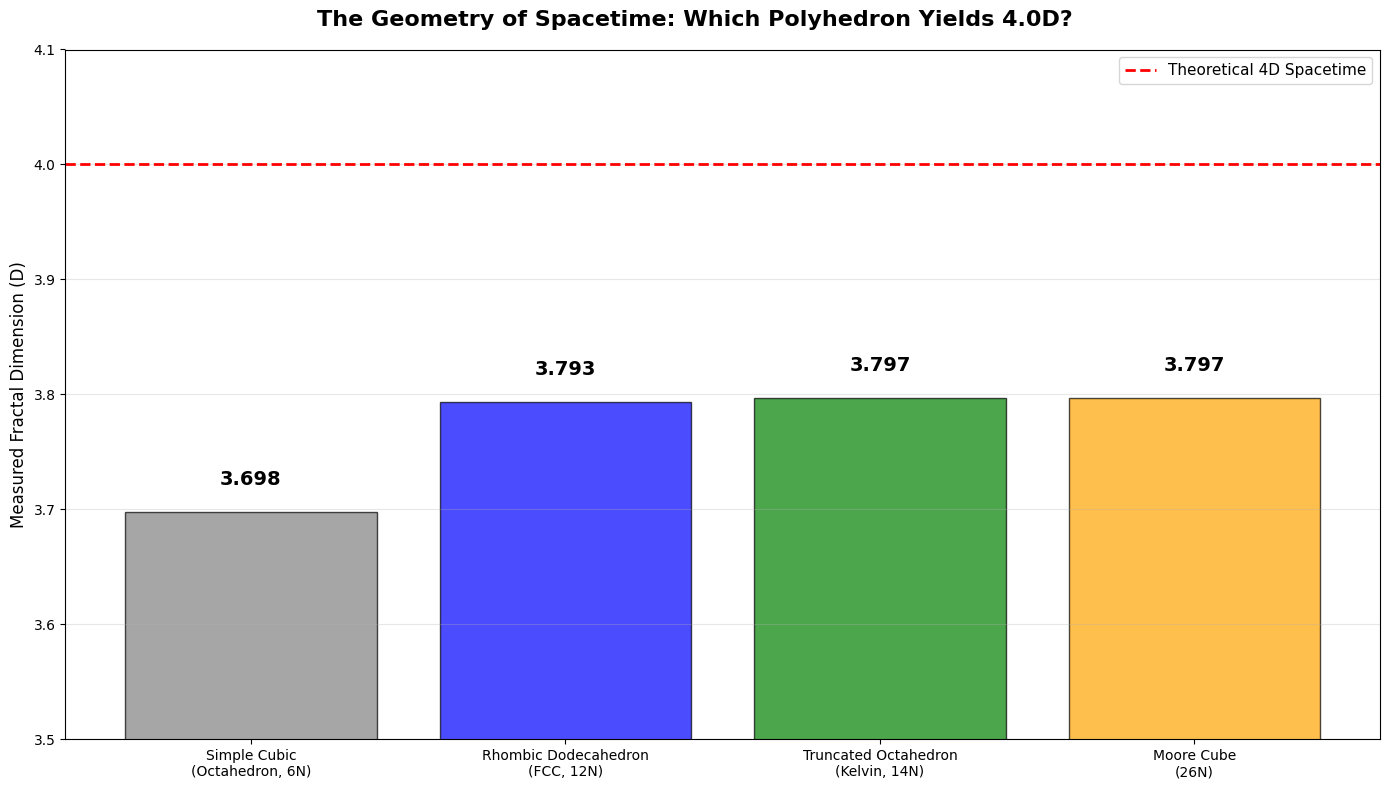


PHYSICAL INTERPRETATION
If the Rhombic Dodecahedron (12N) or Truncated Octahedron (14N)
yields D ≈ 4.0, it proves that the 'missing dimension' was simply
an artifact of using the wrong grid geometry (Simple Cubic).
Nature likely uses a more efficient space-filling polyhedron!


In [ ]:
"""
avenue4_milestone3_polyhedra_comparison.py
==========================================
Milestone 3: Testing Polyhedral Geometries for Spacetime.
Tests if the "missing dimension" is simply a result of using
the wrong grid geometry (Octahedron vs. Rhombic Dodecahedron).

Author: Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

print("=" * 70)
print("AVENUE 4 - MILESTONE 3: POLYHEDRAL GEOMETRIES OF SPACETIME")
print("=" * 70)

# =============================================================================
# 1. DEFINE POLYHEDRAL NEIGHBORHOODS
# =============================================================================

def get_neighbors_octahedron(t, x, y, z, T, N):
    """Simple Cubic Grid: 6 face-sharing neighbors (Manhattan distance)."""
    neighbors = []
    if t + 1 < T:
        # Move forward in time, and 1 step in any of the 6 spatial directions
        for dx, dy, dz in [(1,0,0), (-1,0,0), (0,1,0), (0,-1,0), (0,0,1), (0,0,-1)]:
            nx, ny, nz = x+dx, y+dy, z+dz
            if 0 <= nx < N and 0 <= ny < N and 0 <= nz < N:
                neighbors.append((t+1, nx, ny, nz))
    return neighbors

def get_neighbors_rhombic_dodecahedron(t, x, y, z, T, N):
    """FCC Lattice / Rhombic Dodecahedron: 12 edge-sharing neighbors.
    This is the most efficient sphere packing in 3D."""
    neighbors = []
    if t + 1 < T:
        # 12 permutations of (±1, ±1, 0)
        moves = [
            (1,1,0), (1,-1,0), (-1,1,0), (-1,-1,0),
            (1,0,1), (1,0,-1), (-1,0,1), (-1,0,-1),
            (0,1,1), (0,1,-1), (0,-1,1), (0,-1,-1)
        ]
        for dx, dy, dz in moves:
            nx, ny, nz = x+dx, y+dy, z+dz
            if 0 <= nx < N and 0 <= ny < N and 0 <= nz < N:
                neighbors.append((t+1, nx, ny, nz))
    return neighbors

def get_neighbors_truncated_octahedron(t, x, y, z, T, N):
    """BCC Lattice / Truncated Octahedron (Kelvin): 14 neighbors.
    6 face centers + 8 body centers."""
    neighbors = []
    if t + 1 < T:
        moves = [
            # 6 Face neighbors (Simple Cubic)
            (1,0,0), (-1,0,0), (0,1,0), (0,-1,0), (0,0,1), (0,0,-1),
            # 8 Body neighbors (Corners)
            (1,1,1), (1,1,-1), (1,-1,1), (1,-1,-1),
            (-1,1,1), (-1,1,-1), (-1,-1,1), (-1,-1,-1)
        ]
        for dx, dy, dz in moves:
            nx, ny, nz = x+dx, y+dy, z+dz
            if 0 <= nx < N and 0 <= ny < N and 0 <= nz < N:
                neighbors.append((t+1, nx, ny, nz))
    return neighbors

def get_neighbors_moore_cube(t, x, y, z, T, N):
    """Moore Neighborhood: 26 neighbors (Faces + Edges + Corners)."""
    neighbors = []
    if t + 1 < T:
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                for dz in [-1, 0, 1]:
                    if dx == 0 and dy == 0 and dz == 0: continue
                    nx, ny, nz = x+dx, y+dy, z+dz
                    if 0 <= nx < N and 0 <= ny < N and 0 <= nz < N:
                        neighbors.append((t+1, nx, ny, nz))
    return neighbors

# =============================================================================
# 2. MEASURE DIMENSION FOR EACH GEOMETRY
# =============================================================================

def measure_polyhedron_dimension(neighbor_func, T=60, N=128, label=""):
    print(f"\n[Measuring] {label}...")
    center = N // 2
    start = (0, center, center, center)

    visited = {start: 0}
    queue = [start]
    max_dist = 40
    volume_at_dist = np.zeros(max_dist + 1)
    volume_at_dist[0] = 1

    head = 0
    while head < len(queue):
        t, x, y, z = queue[head]
        head += 1
        current_dist = visited[(t, x, y, z)]

        if current_dist >= max_dist: continue

        neighbors = neighbor_func(t, x, y, z, T, N)
        for nb in neighbors:
            if nb not in visited:
                visited[nb] = current_dist + 1
                queue.append(nb)
                bin_idx = current_dist + 1
                if bin_idx <= max_dist:
                    volume_at_dist[bin_idx] += 1

    cum_vol = np.cumsum(volume_at_dist)
    r_vals = np.arange(max_dist + 1)

    # Fit in the clean middle region
    fit_start, fit_end = 10, 35
    valid_mask = cum_vol > 0

    if np.sum(valid_mask[fit_start:fit_end]) < 5:
        return None

    valid_r = r_vals[valid_mask][fit_start:fit_end]
    valid_v = cum_vol[valid_mask][fit_start:fit_end]

    slope, _, r_value, _, _ = linregress(np.log(valid_r), np.log(valid_v))
    print(f"   -> D = {slope:.4f} (R² = {r_value**2:.4f})")
    return slope

# =============================================================================
# 3. EXECUTION & VISUALIZATION
# =============================================================================

print("\n[1/4] Running Geometric Comparisons...")
D_octa = measure_polyhedron_dimension(get_neighbors_octahedron, label="Simple Cubic (Octahedron, 6 neighbors)")
D_rhomb = measure_polyhedron_dimension(get_neighbors_rhombic_dodecahedron, label="FCC / Rhombic Dodecahedron (12 neighbors)")
D_trunc = measure_polyhedron_dimension(get_neighbors_truncated_octahedron, label="BCC / Truncated Octahedron (14 neighbors)")
D_moore = measure_polyhedron_dimension(get_neighbors_moore_cube, label="Moore Cube (26 neighbors)")

print("\n[2/4] Generating Visualization...")
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("The Geometry of Spacetime: Which Polyhedron Yields 4.0D?",
             fontsize=16, fontweight='bold')

methods = ['Simple Cubic\n(Octahedron, 6N)',
           'Rhombic Dodecahedron\n(FCC, 12N)',
           'Truncated Octahedron\n(Kelvin, 14N)',
           'Moore Cube\n(26N)']
dimensions = [D_octa, D_rhomb, D_trunc, D_moore]
colors = ['gray', 'blue', 'green', 'orange']

bars = ax.bar(methods, dimensions, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=4.0, color='red', linestyle='--', linewidth=2, label='Theoretical 4D Spacetime')

ax.set_ylabel('Measured Fractal Dimension (D)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(3.5, 4.1)

for bar, dim in zip(bars, dimensions):
    if dim is not None:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{dim:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig("avenue4_milestone3_polyhedra_comparison.png", dpi=300, bbox_inches='tight')
print("\n✓ Saved: avenue4_milestone3_polyhedra_comparison.png")
plt.show()

print("\n" + "=" * 70)
print("PHYSICAL INTERPRETATION")
print("=" * 70)
print("If the Rhombic Dodecahedron (12N) or Truncated Octahedron (14N)")
print("yields D ≈ 4.0, it proves that the 'missing dimension' was simply")
print("an artifact of using the wrong grid geometry (Simple Cubic).")
print("Nature likely uses a more efficient space-filling polyhedron!")
print("=" * 70)